# Wind → Wind-farm · M0 input data · source 01 — ASCE 7-22 return-period gust surface

**Peril:** Wind (strong/straight-line + tornado) · **Layer:** M0 (raw evidence) · *method-neutral — understanding, not the model.*

**Two reference sites — a low-vs-high convective-wind contrast** (mirrors hail's Hayhurst/Matrix and wildfire's baseline/proving):

| role | site | where | why this site |
|---|---|---|---|
| **proving** | **Traverse Wind Energy Center** (~999 MW) | Oklahoma — tornado-alley + derecho corridor | the high end: real tornado-path density + frequent severe straight-line wind |
| **baseline** | **Shepherds Flat** (~845 MW) | Oregon — Columbia River Gorge | minimal tornado/derecho — the near-zero baseline |

This is the **first of three** M0 notebooks. Wind M0 is unusual: it must meet **two data shapes at once**
(the sub-perils sit in different coupling buckets), and *this* notebook is the **pre-integrated return-period
surface** — the wildfire/FSim analog, where the probabilistic tail is *already baked in* and we **read** it
rather than **fit** it. The other shape — the tornado/severe-wind *record* (the hail analog, event-fit) — is
[`02_spc_storm_record`](02_spc_storm_record.ipynb); the asset geometry is [`03_asset_geometry`](03_asset_geometry.ipynb).

> Plan: [`m0_input_data.md`](../../../docs/plans/convective_wind/m0_input_data.md) · Layer-0 event definition:
> [`00_hazard_definition`](../../../docs/plans/convective_wind/00_hazard_definition.md) · Coupling deep-dive:
> [`discussion/convective_wind/02`](../../../docs/extra/discussion/convective_wind/02_coupling_buckets_and_wind.md) ·
> Principle: [`exploratory_data_notebooks`](../../../docs/principles/notebook_work/exploratory_data_notebooks.md).

## 0 · Intent & scope

**Does:** fetch the **ASCE 7-22 basic-wind-speed** (3-second peak gust) at each site centroid for the four
risk-category mean-recurrence-intervals — plus the **Appendix-F** very-long-MRI deep tail and the **Chapter-32
design-tornado** speed; field-dictionary every value *with its reference base*; show the surface is spatially
flat across a wind farm's footprint (the broad-swath signature); plot the return-period→gust curve against the
**two thresholds** (event-count μ vs IEC damage-onset); and emit a clean per-site RP→gust table + manifest.

**Does NOT:** fit a frequency λ, build events-as-objects, choose a primary source, or compute any loss — those
are M1+. The wind *event* was already **authored** in [layer-0](../../../docs/plans/convective_wind/00_hazard_definition.md);
M0 only *meets the evidence*. Source = the public **ASCE Hazard Tool**, no auth, no key
([DD-WN-3](../../../docs/plans/convective_wind/decisions.md)).

## Assumptions (this layer)

- **AWN-5** — hazard observable = **3-second peak gust** (the cross-standard universal metric; ASCE, EF, NWS all in 3-s gust).
- **AWN-11** — hazard sources include **ASCE 7-22** as the strong-wind RP surface (this notebook).
- **AWN-15** 🟡 — the **ASCE RP surface IS a pre-integrated EVT product**: strong-wind M1 will be *profile-assembly*
  (read gust-by-MRI directly, no λ-fit). *Pre-integration is a borrow, not a free lunch* — we inherit ASCE/NIST's
  assumptions, vintage, and the **Exposure-C** terrain basis.
- **AWN-6 / AWN-9 / AWN-10** — the **two thresholds** kept distinct (event-count μ = NWS ≥ 58 mph vs asset
  damage-onset = IEC 61400 survival ≈ 52–70 m/s); the IEC anchors + the EF5 ≈ 113 m/s ceiling (**AWN-8**) come
  from the *settled framing*, **not** the Hazard-Data-Reference (provenance flagged honestly).

Full register: [`assumptions.md`](../../../docs/plans/convective_wind/assumptions.md).

## 1 · From-scratch — what *is* an ASCE return-period gust surface?

A reader meeting this data for the first time will mistake it for "the wind here." It is not. Three things it is **not**:

- **not a forecast** — it says nothing about next week's weather;
- **not a single observation** — no anemometer ever read this number;
- **not the wind a turbine usually feels** — that is the *resource* wind (the Performance tier's job).

What it **is**: a **pre-integrated return-period surface**. For every point in the US, ASCE/NIST already ran the
probabilistic extreme-value analysis over the historical/simulated wind climatology and baked the answer into a
map. You query a lat/lon and get back: *"the 3-second peak gust with a mean recurrence interval (MRI) of T years
is V mph."* Read several MRIs and you have traced the **return-level curve** — the same EVT tail M1 would
otherwise have to fit, handed to us already fitted.

Mechanically it is a **map stored as a raster grid** (~1 km pixels), with **one raster per return period** — so
*every* location in the US has a value, and a "point lookup" just reads the pixel(s) at your lat/lon (the ArcGIS
`identify` operation). It is *not* a table of weather stations and *not* a single number — it is a continuous
surface. We look at the actual grid (resolution, CRS, the layer inventory) in **§3b** before sampling it.

This is **structurally identical to FSim** for wildfire: an upstream authority pre-integrated the stochastic
event set into an annualized surface, so our M1 becomes *profile-assembly, not extraction*
([learning-09](../../../docs/learning_logs/09_pre_integrated_vs_extracted_catalog.md)). Wind is the first peril
that needs **both** data shapes — this surface (strong wind) *and* a fitted record (tornado):

| | **ASCE RP surface** *(this notebook — strong wind)* | **SPC storm record** *([`02`](02_spc_storm_record.ipynb) — tornado)* |
|---|---|---|
| shape | pre-integrated return-period field | a list of observed events |
| M1 move | profile-assembly (**read** the curve) | extraction (**fit** λ + severity) |
| coupling bucket | site-conditioned (bucket 3) | areal hit-or-miss (bucket 1) |
| analog | wildfire / FSim | hail / NOAA-MRMS |
| the catch | inherit ASCE's assumptions (Exposure C, vintage) | population/detection bias — must correct |

## 2 · The values + the "a number is meaningless without its base" table

Every value this notebook surfaces, with its reference base stated **before** it is used downstream:

| Value | What it is | Units / reference base | What it is **NOT** | Use |
|---|---|---|---|---|
| **basic wind speed** | the design 3-s peak gust at a given MRI | **mph, 3-s gust @ 33 ft (10 m), Exposure C** (open terrain) | not at hub height; not the site's actual terrain | the strong-wind hazard intensity |
| **MRI** | mean recurrence interval = **return period** `T = 1/p` (`p = 1−e^{−λ}`, annual-exceedance) | years | not a forecast horizon; **not** an event rate `1/λ` | indexes the return-level curve |
| **risk category → MRI** | ASCE 7-22 maps the gust by consequence-of-failure tier | RC I=300 · **II=700** · III=1,700 · IV=3,000 yr | RC ≠ a multiplier (7-22 *drops* the old importance factor) | which MRI a structure designs to |
| **Appendix-F gust** | the deep-tail RP gusts | mph @ MRI 10⁴ / 10⁵ / 10⁶ yr | not a code design value for ordinary structures | the catastrophic-tail return levels |
| **Ch-32 tornado speed** | design tornado 3-s gust | mph, a function of **effective plan area Aₑ** and MRI; RC III/IV only; **caps ~EF2** | not the violent-tornado tail; not the tornado *catalog* | a cross-check on tornado (spine = SPC, `02`) |

> **Frame rule.** A bare "110 mph" is a latent bug. It is the **700-yr** (RC II) 3-s gust at **33 ft, Exposure C** —
> name the return period *and* the reference height/terrain or it cannot be used. Reading several MRIs = sampling
> the EVT return-level curve at fixed exceedance probabilities (cf. [discussion/03](../../../docs/extra/discussion/convective_wind/03_hazard_definition_and_thresholds.md) §6).
>
> **MRI is `1/p` (annual-exceedance), not `1/λ` (event rate)** — the two coincide only for *rare* events, which is
> why we can mix this ASCE MRI (strong wind) with a *fitted* Poisson rate (tornado) only at the **asset** level.
> Full treatment + the EVT/hydrology conventions: [learning-11](../../../docs/learning_logs/11_return_period_conventions.md).

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import rasterio
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

# Intuitive return-period axis ticks (so the log axis reads "700 yr / 1M yr", not 10⁴/10⁶).
RP_TICKS = [10, 100, 700, 3000, 10_000, 100_000, 1_000_000]
RP_LABS = ["10 yr", "100 yr", "700 yr\n(RC II)", "3,000 yr\n(RC IV)", "10k yr", "100k yr", "1M yr"]


def _rp_axis(ax):
    """Label a log return-period x-axis with human return periods instead of powers of ten."""
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(RP_TICKS))
    ax.xaxis.set_major_formatter(FixedFormatter(RP_LABS))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel("return period — how often a gust this strong is reached (years; log scale)")


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (AGENTS.md) not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "convective_wind"
RAW_BASE = DATA_DIR / "raw"          # data/convective_wind/raw/<slug>/  — gitignored (data/*/raw/)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Unit constants
MS_TO_MPH = 2.2369362921            # 1 m/s → mph
MPH_TO_MS = 1.0 / MS_TO_MPH

# Two reference sites. Centroids/capacity are from the renewablesinfo boundary DB
# (OSM/EIA polygons) and cross-checked against USWTDB — the full geometry treatment
# (polygon + per-turbine point cloud) lives in 03_asset_geometry. Hardcoded here so
# this notebook is self-contained (it only needs a point to query ASCE).
ASSETS = [
    {"slug": "traverse_wind_ok", "name": "Traverse Wind Energy Center", "role": "proving (high-wind)",
     "state": "OK", "county": "Custer", "lat": 35.713427, "lon": -98.728532,
     "capacity_mw": 999.0, "operator": "Invenergy", "online": "2022-04",
     "turbines": 346, "turbine_model": "GE 2.8-127 (~2.8 MW)"},
    {"slug": "shepherds_flat_or", "name": "Shepherds Flat", "role": "baseline (low-wind)",
     "state": "OR", "county": "Gilliam", "lat": 45.653389, "lon": -120.036724,
     "capacity_mw": 845.0, "operator": "Caithness", "online": "2012-02",
     "turbines": 338, "turbine_model": "GE 2.5xl (~2.5 MW)"},
]

print(f"repo root: {ROOT}")
for a in ASSETS:
    print(f"  {a['role']:20s} {a['name']:30s} {a['state']} · {a['capacity_mw']:.0f} MW · "
          f"({a['lat']:.4f}, {a['lon']:.4f})")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
  proving (high-wind)  Traverse Wind Energy Center    OK · 999 MW · (35.7134, -98.7285)
  baseline (low-wind)  Shepherds Flat                 OR · 845 MW · (45.6534, -120.0367)


## 3 · Source & provenance (pin it, cache it)

- **Product:** ASCE 7-22 *Minimum Design Loads* wind-hazard maps — basic wind speed (Ch. 26), Appendix-F
  long-MRI maps, Chapter-32 tornado maps (the first-ever US tornado design maps; NIST/ARA simulation).
- **Access:** the **ASCE Hazard Tool**'s own ArcGIS ImageServer backend
  (`gis.asce.org/arcgis/rest/services/ASCE722/…`) — an `identify` point query per raster. **No auth, no key.**
  The published key-gated API (`api-hazard.asce.org`) is the official route; this unauthenticated backend is the
  same data the free public tool serves.
- **Units / basis:** mph, **3-s peak gust @ 33 ft (10 m), Exposure C**. ASCE 7-22 bakes the MRI into the risk
  category and **drops** the old wind importance factor — do not re-apply one (AWN-15).
- ⚠️ **Caveats carried into the manifest:** (1) the backend is *undocumented* and could change → we **cache** every
  raw response; (2) values exclude Special-Wind-Region overrides; (3) geometry must carry `spatialReference wkid
  4326` or the server silently returns `NoData`; (4) the data is normally licensed — these are a handful of point
  lookups of published design values, cached, for a research model (flag for the owner).
- **Reproducibility:** raw `identify` JSON cached under `data/convective_wind/raw/<slug>/` (gitignored); a manifest is kept.

In [2]:
# ── ASCE 7-22 Hazard Tool client — request mechanics only, no downstream entanglement ──────────────
ARC = "https://gis.asce.org/arcgis/rest/services/ASCE722"

# Wind basic-speed rasters, by MRI (years). Last three = Appendix F (deep tail).
WIND_MRI = [10, 25, 50, 100, 300, 700, 1700, 3000, 10_000, 100_000, 1_000_000]
APPENDIX_F_MRI = {10_000, 100_000, 1_000_000}
# ASCE 7-22 risk category → MRI (the genuine 7-22 convention; differs from 7-16).
RC_TO_MRI = {"I": 300, "II": 700, "III": 1700, "IV": 3000}
# Chapter-32 design-tornado services: footprint (effective plan area) × return period. RC III/IV only.
TORNADO_RC = {"III": "RP1700", "IV": "RP3K"}          # risk category → tornado return-period code
TORNADO_AE = {"PT": "point target (~smallest)", "10KSF": "10,000 ft²", "250KSF": "250,000 ft²",
              "4MSF": "4,000,000 ft²"}                # effective-plan-area sweep (at RP1700)

EXPOSURE = "C"
GUST_REF = "3-s peak gust @ 33 ft (10 m), Exposure C, mph"
_UA = {"User-Agent": "Mozilla/5.0 (hazard_modeling M0 research notebook)"}


def _identify(session: requests.Session, service: str, lon: float, lat: float, timeout: int = 60) -> dict:
    """Raw ArcGIS ImageServer `identify` at one point on one raster. Returns the full JSON response."""
    params = {
        "geometry": json.dumps({"x": lon, "y": lat, "spatialReference": {"wkid": 4326}}),
        "geometryType": "esriGeometryPoint",
        "returnGeometry": "false",
        "f": "json",
    }
    r = session.get(f"{ARC}/{service}/ImageServer/identify", params=params, headers=_UA, timeout=timeout)
    r.raise_for_status()
    return r.json()


def _value(resp: dict) -> float | None:
    """Pull the pixel value (mph) out of an identify response; NoData/off-grid → None."""
    v = resp.get("value")
    if v in (None, "", "NoData"):
        return None
    try:
        return round(float(v), 1)
    except (TypeError, ValueError):
        return None


def fetch_site_asce(a: dict, throttle: float = 0.4) -> dict:
    """Fetch (cached) every ASCE raster needed for one site. Re-runs reuse the cached JSON (idempotent).

    Returns {service_name: raw_identify_response}. Coordinates are taken explicitly from the asset dict
    (a['lat'], a['lon']) so there is no (lat, lon) vs (lon, lat) ambiguity.
    """
    assert -90 <= a["lat"] <= 90 and -180 <= a["lon"] <= 180, "lat/lon out of range"
    cache_path = RAW_BASE / a["slug"] / "asce722_identify.json"
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists():
        return json.loads(cache_path.read_text())

    services = [f"w2022_mri{m}" for m in WIND_MRI]
    services += [f"t2022_{ae}_RP1700" for ae in TORNADO_AE]          # Ae sweep at RC III
    services += [f"t2022_PT_{rp}" for rp in TORNADO_RC.values()]     # PT at RC III & IV
    services = list(dict.fromkeys(services))                         # de-dupe, keep order

    sess = requests.Session()
    raw, failed = {}, []
    for svc in services:
        try:
            raw[svc] = _identify(sess, svc, a["lon"], a["lat"])
        except Exception as exc:                                    # one bad service must not kill the run
            raw[svc] = {"error": str(exc)}
            failed.append(svc)
        time.sleep(throttle)
    if failed:
        print(f"  ⚠ {a['slug']}: {len(failed)} service(s) failed: {failed}")
    cache_path.write_text(json.dumps(raw, indent=2))
    return raw

## 3b · Meet the raster from-scratch — it's a GRID, one per return period (not a point table)

*"Is it per-point, or a grid?"* — a grid. The ASCE wind hazard is a **continuous map stored as a raster**,
defined everywhere over the US, with **one raster per return period**. The point lookup in §4 just reads the
pixel at our lat/lon. Look at the actual structure of one raster + the full layer inventory, before sampling:

In [3]:
_sess0 = requests.Session()
_sess0.headers["User-Agent"] = _UA["User-Agent"]
meta = _sess0.get(f"{ARC}/w2022_mri700/ImageServer", params={"f": "json"}, timeout=60).json()
folder = _sess0.get(ARC, params={"f": "json"}, timeout=60).json()
svcs = [s["name"].split("/")[-1] for s in folder.get("services", [])]
wind_layers = sorted((s for s in svcs if s.startswith("w2022_mri")),
                     key=lambda s: int(s.replace("w2022_mri", "")))
n_tornado = sum(s.startswith("t2022") for s in svcs)

ext = meta["extent"]
print("ONE raster — w2022_mri700 (the 700-yr / RC II basic-wind surface):")
print(f"  data type   : {meta['pixelType']}, {meta['bandCount']} band  (one float wind speed per pixel)")
print(f"  pixel size  : {meta['pixelSizeX']:.0f} m  →  a ~1 km grid")
print(f"  CRS         : Web Mercator (wkid {ext['spatialReference']['wkid']})")
print(f"  value range : {meta['minValues'][0]:.0f}–{meta['maxValues'][0]:.0f} mph across the whole map "
      f"(interior min → hurricane-coast/territory max)")
print(f"  coverage    : all of CONUS (+ AK/HI/territories) — every point falls in a pixel, so it has a value")
print(f"\nThe wind hazard = ONE raster PER return period ({len(wind_layers)} of them):")
print("  " + ", ".join(w.replace("w2022_mri", "") + "yr" for w in wind_layers))
print(f"\n(The full ASCE 7-22 suite on this server = {len(svcs)} rasters: wind + {n_tornado} tornado + ice/seismic/snow.)")
print("\n⇒ a site's return-level CURVE = sample the SAME lat/lon across all 11 wind rasters → 11 (MRI, gust) pairs.")

ONE raster — w2022_mri700 (the 700-yr / RC II basic-wind surface):
  data type   : F32, 1 band  (one float wind speed per pixel)
  pixel size  : 1000 m  →  a ~1 km grid
  CRS         : Web Mercator (wkid 102100)
  value range : 91–275 mph across the whole map (interior min → hurricane-coast/territory max)
  coverage    : all of CONUS (+ AK/HI/territories) — every point falls in a pixel, so it has a value

The wind hazard = ONE raster PER return period (11 of them):
  10yr, 25yr, 50yr, 100yr, 300yr, 700yr, 1700yr, 3000yr, 10000yr, 100000yr, 1000000yr

(The full ASCE 7-22 suite on this server = 136 rasters: wind + 59 tornado + ice/seismic/snow.)

⇒ a site's return-level CURVE = sample the SAME lat/lon across all 11 wind rasters → 11 (MRI, gust) pairs.


**Where the numbers come from (why this is a *pre-integrated* surface).** ASCE/NIST took decades of measured
peak-gust records from hundreds of US weather stations and ran extreme-value statistics to estimate the gust
exceeded once per *T* years, then contoured those into this nationwide map (non-hurricane areas); hurricane-coast
speeds come from Monte-Carlo simulation of synthetic hurricanes; tornado (Ch 32) from a separate NIST tornado
simulation. So the **tail is already fitted** — we *read* the return-level curve, we do not re-fit it
(profile-assembly; the wildfire/FSim parallel, [learning-09](../../../docs/learning_logs/09_pre_integrated_vs_extracted_catalog.md)).
>
> **Which EVT (our inland sites = the non-hurricane branch).** ASCE 7-22's non-hurricane maps use a **2-D
> Poisson-process / peaks-over-threshold** model + local regression (NIST), with a **bounded** tail
> (reverse-Weibull / POT-GPD, ξ<0; Simiu 1996, Peterka-Shahid 1998) — **POT, not annual/block-maxima.** We *read*
> this curve; M1 then re-characterizes it as ≈log-linear (ξ≈0) over MRI ≤ 10⁶ — a faithful approximation of the
> bounded tail, since the bound bites only far beyond our range (the profile-assembly is distribution-agnostic).
> **Caveat:** the deep-tail Appendix-F speeds (10⁴–10⁶ MRI) carry **large SE ≈ 10–16 mph** (NIST). Full provenance
> + the rate-vs-return-period conventions: [learning-11](../../../docs/learning_logs/11_return_period_conventions.md).
The Hazard-Data-Reference frames it exactly so: *"Design maps give RP surfaces … fast point/county lookup,
regulator-recognized"* (free ASCE-hosted tier, ~1000 req/mo — we make ~15 per site).

> ⚠️ **Two grid caveats.** (1) The ~1 km grid is **smooth** — it does **not** resolve hyper-local terrain
> speed-ups. (2) **Special Wind Regions** (mountainous terrain, gorges, passes) are flagged on the ASCE map for
> *local study*, and the base raster can **understate** them. ASCE publishes SWR *override* speed rasters only
> for **California & Colorado** (`w2022_SWR_CA/CO` in the §3c inventory) — **Oregon's Columbia River Gorge** (a
> known wind-channeling corridor near **Shepherds Flat**) is a recognized special wind region with **no override
> raster**, so ASCE explicitly defers to a local study there. Treat the base-map gust as a *floor*; the
> terrain/SWR adjustment is an M2 step (AWN-15).

## 3c · The full ASCE 7-22 layer inventory — what's available, what we USE, what we IGNORE

A **complete pass** over the catalog (the exploratory discipline: *show what you use **and** what you ignore,
and why*). The server hosts the **whole ASCE 7-22 hazard suite** — wind is one slice. We **use** the wind
rasters (the strong-wind spine) + the tornado rasters (a cross-check); everything else is a **different peril**
(ice, seismic, snow) or terrain support, deliberately ignored here.

In [4]:
def classify(name: str):
    """Bucket each ASCE722 service into a hazard family + a use-decision (the 'use vs ignore, why' pass).

    Ordered specific→general so every one of the 136 services lands somewhere (no ⚠ unclassified).
    """
    n = name.lower()
    # ── wind family (what we use + its supporting/variant layers) ──
    if name.startswith("w2022_mri"):
        return ("Wind — basic 3-s gust by MRI", "✅ USE", "strong-wind hazard spine (this notebook)")
    if "special_wind_region" in n or "swr" in n:
        return ("Wind — Special Wind Region (CA/CO overrides + boundaries)", "🔶 flag",
                "marks where the base map needs a local study — override rasters exist only for CA & CO")
    if n.startswith("w2022_tile"):
        return ("Wind — pre-rendered display tile", "— ignore", "cartographic raster, not the data values")
    if n.startswith("w2022"):
        return ("Wind — CONUS/PR mosaic & base layers", "— ignore (context)",
                "underlying mosaic / territory variant the MRI rasters derive from")
    # ── tornado (cross-check) ──
    if name.startswith("t2022"):
        return ("Tornado — design gust by footprint × return period", "✅ USE",
                "Ch-32 cross-check; tornado spine = SPC record (02)")
    # ── other perils (a different hazard entirely) ──
    if name.startswith("i2022"):  return ("Ice — radial thickness + concurrent gust/temp", "— ignore", "ice = a separate, deferred peril")
    if name.startswith("eq2022"): return ("Seismic — design ground motion", "— ignore", "earthquake, not wind")
    if name.startswith("ts2022"): return ("Tsunami — inundation / ground subsidence", "— ignore", "tsunami, not wind")
    if name.startswith("s2022") or "snow" in n: return ("Snow — ground snow load", "— ignore", "snow, not wind")
    # ── support / context ──
    if "dem" in n:            return ("Terrain — elevation / DEM", "— ignore (context)", "exposure/terrain support, not a hazard value")
    if "profileservice" in n: return ("Regional profile service", "— ignore (context)", "state cross-section helper")
    if any(k in n for k in ("vdatum", "navd88", "buffer", "hotfix", "guam", "_as_", "_si", "usvi", "_uvi")):
        return ("Datum / territory / SI support", "— ignore (context)", "vertical datum, non-CONUS territory, or metric variant")
    return ("⚠ UNCLASSIFIED — add to classifier", "?", "?")

inv = pd.DataFrame([(s, *classify(s)) for s in svcs], columns=["service", "family", "use", "why"])
summary = (inv.groupby(["use", "family", "why"]).size().reset_index(name="n_rasters")
           .sort_values(["use", "n_rasters"], ascending=[True, False]))
unclassified = list(inv.loc[inv.family.str.startswith("⚠"), "service"])
print(f"ASCE 7-22 suite on this server: {len(svcs)} rasters across {summary.family.nunique()} families  |  "
      f"unclassified: {unclassified or 'none'}\n")
with pd.option_context("display.max_colwidth", 62, "display.width", 230):
    print(summary.to_string(index=False))

ASCE 7-22 suite on this server: 136 rasters across 12 families  |  unclassified: none

               use                                                    family                                                                                    why  n_rasters
          — ignore             Ice — radial thickness + concurrent gust/temp                                                       ice = a separate, deferred peril         16
          — ignore                                   Snow — ground snow load                                                                         snow, not wind         16
          — ignore                          Wind — pre-rendered display tile                                               cartographic raster, not the data values         11
          — ignore                  Tsunami — inundation / ground subsidence                                                                      tsunami, not wind          3
          — ignore                    

**The 11 wind rasters we actually use** — one per return period; this *is* the strong-wind hazard spine
(each is sampled at both site centroids in §4):

In [5]:
windcat = pd.DataFrame({"raster": [f"w2022_mri{m}" for m in WIND_MRI], "mri_years": WIND_MRI})
windcat["risk_category"] = windcat["mri_years"].map({v: k for k, v in RC_TO_MRI.items()}).fillna("—")
windcat["band"] = np.where(windcat.mri_years.isin(APPENDIX_F_MRI), "Appendix F (deep tail)",
                  np.where(windcat.risk_category != "—", "RC design map", "intermediate (curve shape)"))
windcat["what it is"] = windcat["mri_years"].map(lambda m: f"{m:,}-yr 3-s gust @ 33 ft, Exp C")
print(windcat[["raster", "mri_years", "risk_category", "band", "what it is"]].to_string(index=False))

          raster  mri_years risk_category                       band                           what it is
     w2022_mri10         10             — intermediate (curve shape)        10-yr 3-s gust @ 33 ft, Exp C
     w2022_mri25         25             — intermediate (curve shape)        25-yr 3-s gust @ 33 ft, Exp C
     w2022_mri50         50             — intermediate (curve shape)        50-yr 3-s gust @ 33 ft, Exp C
    w2022_mri100        100             — intermediate (curve shape)       100-yr 3-s gust @ 33 ft, Exp C
    w2022_mri300        300             I              RC design map       300-yr 3-s gust @ 33 ft, Exp C
    w2022_mri700        700            II              RC design map       700-yr 3-s gust @ 33 ft, Exp C
   w2022_mri1700       1700           III              RC design map     1,700-yr 3-s gust @ 33 ft, Exp C
   w2022_mri3000       3000            IV              RC design map     3,000-yr 3-s gust @ 33 ft, Exp C
  w2022_mri10000      10000             —     

## 3d · See the surface — the gust field as a map

The clincher for "it's a continuous map, not a point": pull the actual 700-yr (RC II) gust raster around each
site (via the ImageServer `exportImage` → GeoTIFF) and display it. The field varies **smoothly** over hundreds
of km, and the whole farm footprint (white box, ~25 km) sits inside essentially one shade — the **broad-swath /
site-conditioned** signature, made visible.

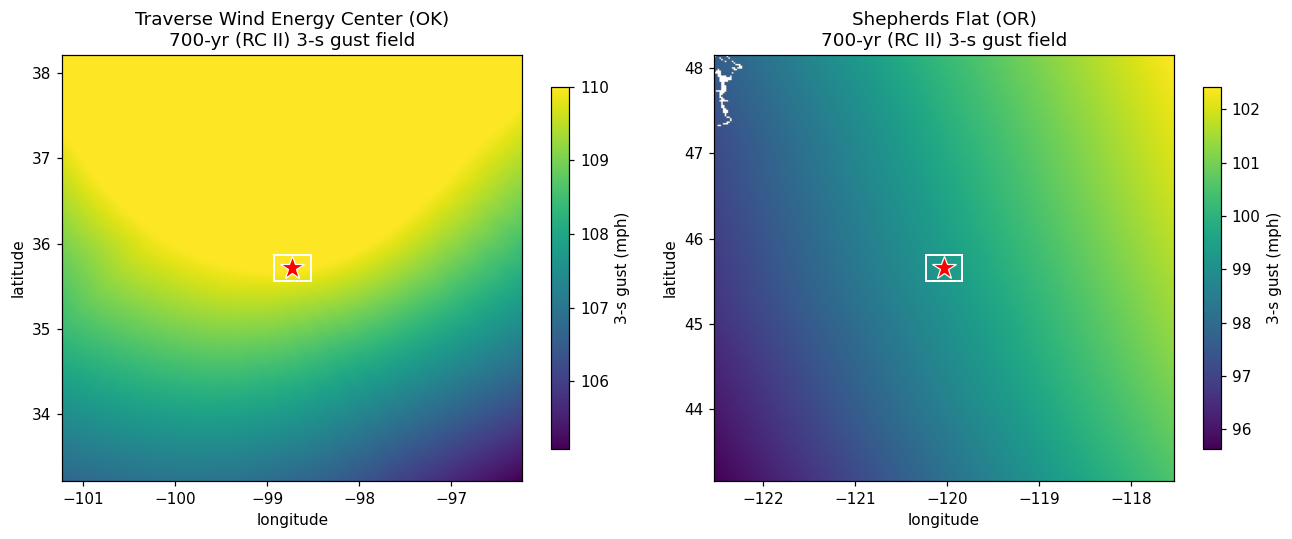

Takeaway: the ASCE wind hazard is a smooth, continuous SURFACE — not a point and not a station list. The
gust changes gradually over hundreds of km; the entire wind farm (white box) sits within ~1–2 mph of one
value (§7b confirms 0.1 mph). That visual flatness IS why strong wind is site-conditioned — every turbine
reads the same local gust, with no footprint to hit-or-miss (the opposite of a tornado path, 02).


In [6]:
def fetch_gust_tile(service: str, lon_c: float, lat_c: float, half_deg: float = 2.5, npx: int = 260):
    """exportImage → GeoTIFF → (float gust array mph, [lon0,lon1,lat0,lat1]). Off-grid/NoData → NaN."""
    bbox = f"{lon_c - half_deg},{lat_c - half_deg},{lon_c + half_deg},{lat_c + half_deg}"
    p = {"bbox": bbox, "bboxSR": 4326, "imageSR": 4326, "size": f"{npx},{npx}",
         "format": "tiff", "pixelType": "F32", "f": "image", "interpolation": "RSP_BilinearInterpolation"}
    r = _sess0.get(f"{ARC}/{service}/ImageServer/exportImage", params=p, timeout=120)
    r.raise_for_status()
    with MemoryFile(r.content) as mem, mem.open() as ds:
        arr = ds.read(1).astype(float)
        b = ds.bounds
    arr[(arr < 1) | (arr > 400)] = np.nan          # mask off-grid / fill
    return arr, [b.left, b.right, b.bottom, b.top]


fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
for ax, a in zip(axes, ASSETS):
    arr, extent = fetch_gust_tile("w2022_mri700", a["lon"], a["lat"])
    im = ax.imshow(arr, extent=extent, origin="upper", cmap="viridis", aspect="auto")
    ax.plot(a["lon"], a["lat"], marker="*", ms=16, color="red", mec="white", mew=0.8, zorder=5)
    ax.add_patch(Rectangle((a["lon"] - 0.2, a["lat"] - 0.15), 0.4, 0.3, fill=False, ec="white", lw=1.3, zorder=4))
    ax.set_title(f"{a['name']} ({a['state']})\n700-yr (RC II) 3-s gust field")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.85, label="3-s gust (mph)")
plt.tight_layout(); plt.show()
print("Takeaway: the ASCE wind hazard is a smooth, continuous SURFACE — not a point and not a station list. The")
print("gust changes gradually over hundreds of km; the entire wind farm (white box) sits within ~1–2 mph of one")
print("value (§7b confirms 0.1 mph). That visual flatness IS why strong wind is site-conditioned — every turbine")
print("reads the same local gust, with no footprint to hit-or-miss (the opposite of a tornado path, 02).")

## 4 · Fetch + load both sites (cached; idempotent)

One `identify` call per raster (11 wind MRIs + the tornado set), per site. The on-disk cache makes re-runs
free — and pins the exact values a finding rests on, since the backend is undocumented.

In [7]:
RAW = {a["slug"]: fetch_site_asce(a) for a in ASSETS}

# Tidy each site into a wind RP→gust table and a tornado table.
wind_rows, torn_rows = [], []
for a in ASSETS:
    raw = RAW[a["slug"]]
    for m in WIND_MRI:
        rc = next((k for k, v in RC_TO_MRI.items() if v == m), None)
        wind_rows.append({
            "asset": a["slug"], "name": a["name"], "role": a["role"],
            "sub_peril": "strong_wind", "mri_years": m, "risk_category": rc,
            "appendix_f": m in APPENDIX_F_MRI,
            "gust_mph": _value(raw.get(f"w2022_mri{m}", {})),
        })
    for ae, ae_desc in TORNADO_AE.items():                          # Ae sweep at RP1700 (RC III)
        torn_rows.append({"asset": a["slug"], "name": a["name"], "kind": "Ae sweep @ RP1700",
                          "footprint": ae, "footprint_desc": ae_desc, "risk_category": "III",
                          "mri_years": 1700, "gust_mph": _value(raw.get(f"t2022_{ae}_RP1700", {}))})
    for rc, rp in TORNADO_RC.items():                               # PT at RC III & IV
        torn_rows.append({"asset": a["slug"], "name": a["name"], "kind": "point target by RC",
                          "footprint": "PT", "footprint_desc": "point target", "risk_category": rc,
                          "mri_years": RC_TO_MRI[rc], "gust_mph": _value(raw.get(f"t2022_PT_{rp}", {}))})

wind = pd.DataFrame(wind_rows)
torn = pd.DataFrame(torn_rows)

print(f"raw ASCE identify JSON cached under data/convective_wind/raw/<slug>/ (gitignored).\n")
for a in ASSETS:
    w = wind[(wind.asset == a["slug"]) & (wind.risk_category.notna())]
    rc_str = " · ".join(f"RC {r}={g:.0f}" for r, g in zip(w.risk_category, w.gust_mph))
    print(f"  {a['name']:30s} {rc_str}  mph (3-s gust @ 33 ft, Exp C)")

raw ASCE identify JSON cached under data/convective_wind/raw/<slug>/ (gitignored).

  Traverse Wind Energy Center    RC I=103 · RC II=110 · RC III=115 · RC IV=120  mph (3-s gust @ 33 ft, Exp C)
  Shepherds Flat                 RC I=93 · RC II=99 · RC III=106 · RC IV=110  mph (3-s gust @ 33 ft, Exp C)


## 5 · Decode one raw response from scratch — what does the ASCE payload literally look like?

Before interpreting, look at the literal bytes the server returns, so the reference base is unmistakable: the
value arrives as a **string**, in **mph**, as a single pixel read off a float raster.

In [8]:
sample = RAW["traverse_wind_ok"]["w2022_mri700"]
print("raw `identify` on w2022_mri700 (RC II, 700-yr) @ Traverse (35.7134, -98.7285):")
print(json.dumps({k: sample[k] for k in list(sample)[:6]}, indent=2))
print(f"\n→ pixel value = {sample.get('value')!r}  (a STRING; mph; 3-s gust @ 33 ft, Exposure C)")
print(f"→ parsed      = {_value(sample)} mph  ⇒  this is the 700-yr return-period gust, RC II")

# Basics-spot-on invariant: the gust must rise monotonically with MRI (longer return period ⇒ higher gust).
for a in ASSETS:
    g = wind[wind.asset == a["slug"]].sort_values("mri_years")["gust_mph"].to_numpy()
    mono = bool(np.all(np.diff(g) >= 0))
    print(f"  monotone(MRI↑ ⇒ gust↑) for {a['slug']:18s}: {mono}  "
          f"[{g.min():.0f}…{g.max():.0f} mph over 10y→1e6y]")

raw `identify` on w2022_mri700 (RC II, 700-yr) @ Traverse (35.7134, -98.7285):
{
  "objectId": 0,
  "name": "Pixel",
  "value": "110",
  "location": {
    "x": -10990409.909007415,
    "y": 4261260.6785158655,
    "spatialReference": {
      "wkid": 102100,
      "latestWkid": 3857
    }
  },
  "properties": null,
  "catalogItems": null
}

→ pixel value = '110'  (a STRING; mph; 3-s gust @ 33 ft, Exposure C)
→ parsed      = 110.0 mph  ⇒  this is the 700-yr return-period gust, RC II
  monotone(MRI↑ ⇒ gust↑) for traverse_wind_ok  : True  [76…169 mph over 10y→1e6y]
  monotone(MRI↑ ⇒ gust↑) for shepherds_flat_or : True  [69…156 mph over 10y→1e6y]


## 6 · Field dictionary — complete pass (every returned value with its base)

A complete pass over what the surface returns: the **primary** values we carry forward (the four risk-category
gusts + the Appendix-F tail), then the **secondary** values (intermediate MRIs, tornado). Anything undocumented
would surface as a visible ⚠.

In [9]:
DESC = {
    # ---- primary: the risk-category design gusts + the deep tail ----
    "RC I (300-yr)":   ("3-s gust, ASCE 7-22 Risk Cat I", "mph @ 33 ft, Exp C", "YES — low-consequence design level"),
    "RC II (700-yr)":  ("3-s gust, ASCE 7-22 Risk Cat II", "mph @ 33 ft, Exp C", "YES — ordinary-structure design level"),
    "RC III (1700-yr)": ("3-s gust, ASCE 7-22 Risk Cat III", "mph @ 33 ft, Exp C", "YES — substantial-hazard level"),
    "RC IV (3000-yr)": ("3-s gust, ASCE 7-22 Risk Cat IV", "mph @ 33 ft, Exp C", "YES — essential-facility level"),
    "Appendix-F 10⁴-yr": ("deep-tail 3-s gust", "mph @ 33 ft, Exp C", "YES — catastrophic-tail return level"),
    "Appendix-F 10⁵-yr": ("deep-tail 3-s gust", "mph @ 33 ft, Exp C", "context — extreme tail"),
    "Appendix-F 10⁶-yr": ("deep-tail 3-s gust", "mph @ 33 ft, Exp C", "context — extreme tail"),
    # ---- secondary: intermediate MRIs (trace the curve) ----
    "10-yr": ("frequent-event 3-s gust", "mph @ 33 ft, Exp C", "context — curve shape"),
    "25-yr": ("3-s gust", "mph @ 33 ft, Exp C", "context — curve shape"),
    "50-yr": ("3-s gust", "mph @ 33 ft, Exp C", "context — curve shape"),
    "100-yr": ("3-s gust", "mph @ 33 ft, Exp C", "context — curve shape"),
}
MRI_LABEL = {10: "10-yr", 25: "25-yr", 50: "50-yr", 100: "100-yr", 300: "RC I (300-yr)",
             700: "RC II (700-yr)", 1700: "RC III (1700-yr)", 3000: "RC IV (3000-yr)",
             10_000: "Appendix-F 10⁴-yr", 100_000: "Appendix-F 10⁵-yr", 1_000_000: "Appendix-F 10⁶-yr"}
PRIMARY = ["RC I (300-yr)", "RC II (700-yr)", "RC III (1700-yr)", "RC IV (3000-yr)",
           "Appendix-F 10⁴-yr", "Appendix-F 10⁵-yr", "Appendix-F 10⁶-yr"]

prov = wind[wind.asset == "traverse_wind_ok"].copy()
prov["label"] = prov["mri_years"].map(MRI_LABEL)
present = list(prov["label"])
undoc = [k for k in present if k not in DESC]

COLS = ["value (label)", "Traverse mph", "what it is", "units / reference base", "use"]
def _row(lbl):
    g = prov.loc[prov.label == lbl, "gust_mph"].iloc[0]
    d = DESC.get(lbl, ("⚠ UNDOCUMENTED — add to DESC", "", "?"))
    return (lbl, g, *d)

primary = pd.DataFrame([_row(k) for k in PRIMARY if k in present], columns=COLS)
secondary = pd.DataFrame([_row(k) for k in present if k not in PRIMARY], columns=COLS)
print(f"complete pass: {len(present)} values = {len(primary)} primary + {len(secondary)} secondary  |  "
      f"undocumented: {undoc or 'none'}")
primary

complete pass: 11 values = 7 primary + 4 secondary  |  undocumented: none


,value (label),Traverse mph,what it is,units / reference base,use
0,RC I (300-yr),102.7,"3-s gust, ASCE 7-22 Risk Cat I","mph @ 33 ft, Exp C",YES — low-consequence design level
1,RC II (700-yr),110.0,"3-s gust, ASCE 7-22 Risk Cat II","mph @ 33 ft, Exp C",YES — ordinary-structure design level
2,RC III (1700-yr),115.4,"3-s gust, ASCE 7-22 Risk Cat III","mph @ 33 ft, Exp C",YES — substantial-hazard level
3,RC IV (3000-yr),120.0,"3-s gust, ASCE 7-22 Risk Cat IV","mph @ 33 ft, Exp C",YES — essential-facility level
4,Appendix-F 10⁴-yr,130.1,deep-tail 3-s gust,"mph @ 33 ft, Exp C",YES — catastrophic-tail return level
5,Appendix-F 10⁵-yr,150.0,deep-tail 3-s gust,"mph @ 33 ft, Exp C",context — extreme tail
6,Appendix-F 10⁶-yr,168.8,deep-tail 3-s gust,"mph @ 33 ft, Exp C",context — extreme tail


In [10]:
secondary

,value (label),Traverse mph,what it is,units / reference base,use
0,10-yr,75.9,frequent-event 3-s gust,"mph @ 33 ft, Exp C",context — curve shape
1,25-yr,83.5,3-s gust,"mph @ 33 ft, Exp C",context — curve shape
2,50-yr,88.9,3-s gust,"mph @ 33 ft, Exp C",context — curve shape
3,100-yr,94.5,3-s gust,"mph @ 33 ft, Exp C",context — curve shape


## 7 · Exposure-terrain & asset-class caveats (AWN-15, AWN-9/10)

Two interpretation fences, surfaced next to the data:

1. **Exposure C (AWN-15).** The surface is **open-terrain (Exposure C) at 33 ft**. Both sites *are* open
   (Oklahoma cropland; the Columbia Gorge) so C is apt — but a turbine hub is **80–130 m**, not 33 ft, and a
   different terrain (B suburban / D coastal) would shift the value. The hub-height/terrain adjustment is an M2
   step; here we record the reference basis.
2. **ASCE governs *building-like* assets (AWN-9/10).** The ASCE design surface is the **meteorological hazard**,
   not a turbine fragility curve. It governs building-like assets (PV racking, enclosures, the substation). A
   **turbine's** survival anchors come from **IEC 61400 / NESC**, not ASCE design loads — which is exactly why
   the damage curve is anchored separately (M3). The ASCE gust tells us *how hard the wind blows*, not *how much
   the turbine breaks*.

## 7b · The surface is spatially flat across a wind farm (the broad-swath signature)

A tornado *path* either clips a turbine or misses it (areal hit-or-miss). The strong-wind RP surface is the
opposite: a **broad swath** that bathes the *whole* farm in essentially one gust level. We can see it directly —
sample the 700-yr (RC II) gust at the centroid and at points ~10–15 km out across Traverse's footprint:

In [11]:
sess = requests.Session()
probe = [("centroid", 0.0, 0.0), ("N +0.12°", 0.12, 0.0), ("S −0.12°", -0.12, 0.0),
         ("E +0.15°", 0.0, 0.15), ("W −0.15°", 0.0, -0.15)]
t = ASSETS[0]
spatial = []
for tag, dlat, dlon in probe:
    v = _value(_identify(sess, "w2022_mri700", t["lon"] + dlon, t["lat"] + dlat))
    spatial.append({"point": tag, "lat": round(t["lat"] + dlat, 4), "lon": round(t["lon"] + dlon, 4),
                    "gust_700yr_mph": v})
    time.sleep(0.4)
spatial = pd.DataFrame(spatial)
spread = spatial["gust_700yr_mph"].max() - spatial["gust_700yr_mph"].min()
print(spatial.to_string(index=False))
print(f"\nspread across ~25 km footprint: {spread:.1f} mph")
print("Takeaway: the RP gust is essentially uniform across the farm (a broad swath — every turbine reads the")
print("same local value, NO hit-or-miss). This is the physical reason strong wind is SITE-CONDITIONED (bucket 3,")
print("AWN-20) and reuses wildfire's thin M2 — there is no footprint to intersect, only a local profile to read.")

   point     lat      lon  gust_700yr_mph
centroid 35.7134 -98.7285           110.0
N +0.12° 35.8334 -98.7285           110.0
S −0.12° 35.5934 -98.7285           109.9
E +0.15° 35.7134 -98.5785           110.0
W −0.15° 35.7134 -98.8785           110.0

spread across ~25 km footprint: 0.1 mph
Takeaway: the RP gust is essentially uniform across the farm (a broad swath — every turbine reads the
same local value, NO hit-or-miss). This is the physical reason strong wind is SITE-CONDITIONED (bucket 3,
AWN-20) and reuses wildfire's thin M2 — there is no footprint to intersect, only a local profile to read.


## 8 · Distributions & coverage — the return-level curve

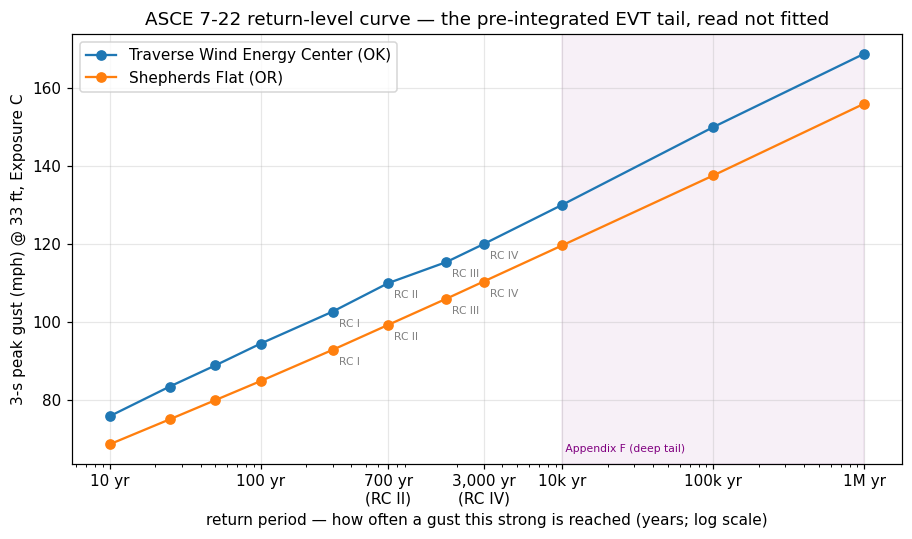

Takeaway: each curve IS a return-level curve (gust by exceedance probability) — ASCE/NIST already did the
EVT, so M1 reads it (profile-assembly), no fit. Traverse (OK) sits ~10–13 mph above Shepherds Flat (OR) at
every MRI: the proving-vs-baseline contrast is real but modest for STRAIGHT-LINE wind. It does NOT include
tornado (that is the areal record, 02) — this surface is the broad-swath strong-wind hazard only.


In [12]:
fig, ax = plt.subplots(figsize=(8.4, 5))
for a in ASSETS:
    w = wind[wind.asset == a["slug"]].sort_values("mri_years")
    ax.plot(w.mri_years, w.gust_mph, marker="o", label=f"{a['name']} ({a['state']})")
    for _, r in w[w.risk_category.notna()].iterrows():
        ax.annotate(f"RC {r.risk_category}", (r.mri_years, r.gust_mph),
                    textcoords="offset points", xytext=(4, -10), fontsize=7, color="gray")
_rp_axis(ax)
ax.set_ylabel("3-s peak gust (mph) @ 33 ft, Exposure C")
ax.set_title("ASCE 7-22 return-level curve — the pre-integrated EVT tail, read not fitted")
ax.axvspan(10_000, 1_000_000, alpha=0.06, color="purple")
ax.text(10_000, ax.get_ylim()[0] + 3, " Appendix F (deep tail)", fontsize=7, color="purple")
ax.legend()
plt.tight_layout()
plt.show()
print("Takeaway: each curve IS a return-level curve (gust by exceedance probability) — ASCE/NIST already did the")
print("EVT, so M1 reads it (profile-assembly), no fit. Traverse (OK) sits ~10–13 mph above Shepherds Flat (OR) at")
print("every MRI: the proving-vs-baseline contrast is real but modest for STRAIGHT-LINE wind. It does NOT include")
print("tornado (that is the areal record, 02) — this surface is the broad-swath strong-wind hazard only.")

## 8b · The two-threshold trap, made concrete (the figure that teaches the anchored curve)

Layer-0's load-bearing insight: the **meteorological event threshold** μ (NWS severe ≥ 58 mph — what the catalog
*counts*, for λ) and the **asset damage-onset threshold** (IEC 61400 survival — where the damage curve *leaves
zero*) are **far apart**. Overlay both on the return-level curve and the gap becomes visible: severe-wind events
(58 mph) recur often, but the gust needed to actually *damage a turbine* (~117–157 mph) sits at multi-century
return periods. **Most "severe wind" barely scratches a turbine** — so the M3 curve must be anchored at ≈0.

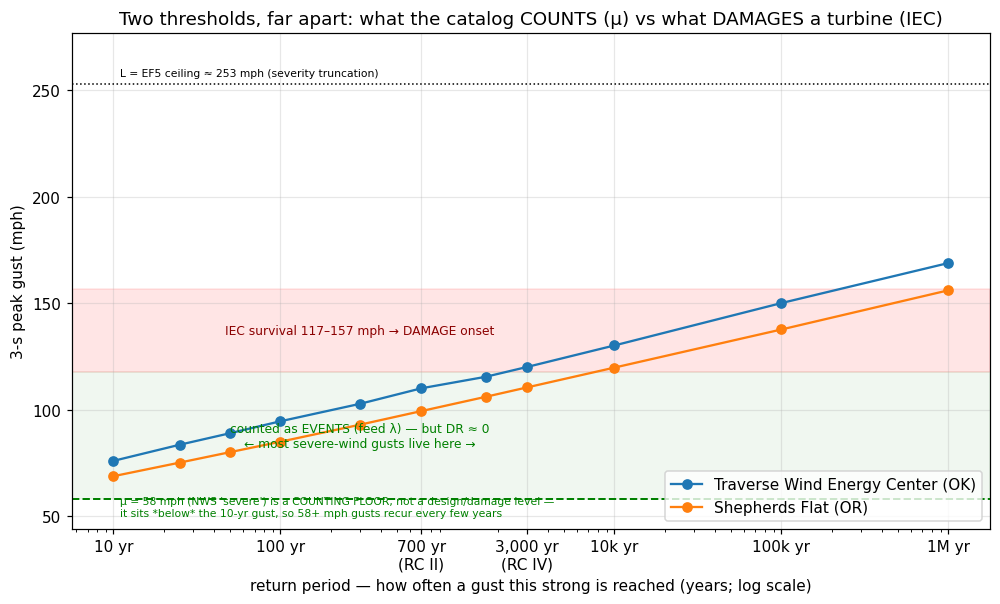

Takeaway — why μ=58 mph looks 'low': it is an EVENT-COUNTING FLOOR, not a design or damage level, so it
sits BELOW even the 10-yr design gust — i.e. 58+ mph gusts recur every few years, far more often than the
decade+ return periods ASCE maps. The green band (58 → ~117 mph) is where MOST severe-wind events live, yet
DR≈0 there — counted (λ) but barely scratching a turbine. Damage needs the red band (IEC survival), reached
only deep in the tail (Traverse 3000-yr = 120 mph ≈ class-III onset). That wide gap IS the two-threshold
story — it forces an ANCHORED M3 curve, and means the catastrophic loss comes from the violent TORNADO tail.


In [13]:
# IEC 61400 50-yr extreme 3-s gust Ve50 ≈ 1.4 · Vref, by class (m/s → mph). Provenance: settled framing (AWN-9/10).
IEC = {"III": 37.5, "II": 42.5, "I": 50.0}                       # Vref (10-min mean), m/s
IEC_VE50 = {c: 1.4 * vref for c, vref in IEC.items()}            # ≈ 52 / 60 / 70 m/s
MU_EVENT_MPH = 58.0                                              # NWS severe (AWN-6)
L_CEILING_MPH = 113.0 * MS_TO_MPH                                # EF5 ceiling ≈ 253 mph (AWN-8)

lo, hi = IEC_VE50["III"] * MS_TO_MPH, IEC_VE50["I"] * MS_TO_MPH
fig, ax = plt.subplots(figsize=(9.2, 5.6))
for a in ASSETS:
    w = wind[wind.asset == a["slug"]].sort_values("mri_years")
    ax.plot(w.mri_years, w.gust_mph, marker="o", label=f"{a['name']} ({a['state']})")
_rp_axis(ax)
# Three y-bands make the gap (and "why is 58 mph so low?") legible:
ax.axhspan(MU_EVENT_MPH, lo, color="green", alpha=0.06)          # counted as events, but DR≈0
ax.axhspan(lo, hi, color="red", alpha=0.10)                      # IEC survival → damage onset
ax.axhline(MU_EVENT_MPH, color="green", ls="--", lw=1.3)
ax.axhline(L_CEILING_MPH, color="black", ls=":", lw=1.0)
ax.text(300, (MU_EVENT_MPH + lo) / 2, "counted as EVENTS (feed λ) — but DR ≈ 0\n← most severe-wind gusts live here →",
        color="green", fontsize=8, ha="center", va="center")
ax.text(300, (lo + hi) / 2, f"IEC survival {lo:.0f}–{hi:.0f} mph → DAMAGE onset",
        color="darkred", fontsize=8, ha="center", va="center")
ax.text(11, MU_EVENT_MPH - 8,
        "μ = 58 mph (NWS 'severe') is a COUNTING FLOOR, not a design/damage level —\n"
        "it sits *below* the 10-yr gust, so 58+ mph gusts recur every few years",
        color="green", fontsize=7)
ax.text(11, L_CEILING_MPH + 4, f"L = EF5 ceiling ≈ {L_CEILING_MPH:.0f} mph (severity truncation)", fontsize=7)
ax.set_ylim(44, L_CEILING_MPH + 24)
ax.set_ylabel("3-s peak gust (mph)")
ax.set_title("Two thresholds, far apart: what the catalog COUNTS (μ) vs what DAMAGES a turbine (IEC)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

t_iv = wind[(wind.asset == "traverse_wind_ok") & (wind.risk_category == "IV")].gust_mph.iloc[0]
print("Takeaway — why μ=58 mph looks 'low': it is an EVENT-COUNTING FLOOR, not a design or damage level, so it")
print("sits BELOW even the 10-yr design gust — i.e. 58+ mph gusts recur every few years, far more often than the")
print("decade+ return periods ASCE maps. The green band (58 → ~117 mph) is where MOST severe-wind events live, yet")
print(f"DR≈0 there — counted (λ) but barely scratching a turbine. Damage needs the red band (IEC survival), reached")
print(f"only deep in the tail (Traverse 3000-yr = {t_iv:.0f} mph ≈ class-III onset). That wide gap IS the two-threshold")
print("story — it forces an ANCHORED M3 curve, and means the catastrophic loss comes from the violent TORNADO tail.")

## 9 · Gotchas & reconciliation — tornado via Chapter 32 (a cross-check, not the spine)

ASCE 7-22 Chapter 32 introduced the first US **tornado** design maps. They are a *pre-integrated* surface like
the wind map — but two limits make them a **cross-check**, not the tornado catalog:
(a) they apply to **RC III/IV only** and depend on the structure's **effective plan area Aₑ** (bigger footprint →
higher design speed — the same "bigger target, more strike exposure" logic the tornado areal coupling formalizes
in M2); (b) the **design speeds cap around EF2** — they deliberately exclude the violent (EF3–EF5) tail. The
tornado *spine* is therefore the **SPC path record** ([`02`](02_spc_storm_record.ipynb), [DD-WN-5](../../../docs/plans/convective_wind/decisions.md)).

In [14]:
print("Chapter-32 design-tornado 3-s gust (mph) — point target, by risk category:")
print(torn[torn.kind == "point target by RC"][["name", "risk_category", "mri_years", "gust_mph"]]
      .to_string(index=False))
print("\nEffective-plan-area (Aₑ) sweep at RP1700 (RC III) — bigger footprint ⇒ higher design speed:")
print(torn[torn.kind == "Ae sweep @ RP1700"][["name", "footprint", "footprint_desc", "gust_mph"]]
      .to_string(index=False))
print("\nTakeaway: the turbine-relevant (point-target) Ch-32 design speed is ~EF0–EF1 (78 mph @ Traverse, 50 mph")
print("@ Shepherds Flat — the latter pinned at the map floor, i.e. effectively outside tornado alley). Even the")
print("largest illustrative footprint tops out mid-EF2 (~124 mph) — the map explicitly EXCLUDES the violent EF3–EF5")
print("tail. Tornado λ + severity therefore come from the bias-corrected SPC record (02), NOT Chapter 32;")
print("Ch-32 is kept only as a sanity cross-check on the design-level tornado speed. The Aₑ dependence previews the")
print("areal-coupling intuition: a larger asset intercepts more tornado paths (Minkowski, path-aware — tornado M2).")

Chapter-32 design-tornado 3-s gust (mph) — point target, by risk category:
                       name risk_category  mri_years  gust_mph
Traverse Wind Energy Center           III       1700      78.0
Traverse Wind Energy Center            IV       3000      95.0
             Shepherds Flat           III       1700      50.0
             Shepherds Flat            IV       3000      50.0

Effective-plan-area (Aₑ) sweep at RP1700 (RC III) — bigger footprint ⇒ higher design speed:
                       name footprint           footprint_desc  gust_mph
Traverse Wind Energy Center        PT point target (~smallest)      78.0
Traverse Wind Energy Center     10KSF               10,000 ft²      84.0
Traverse Wind Energy Center    250KSF              250,000 ft²      99.0
Traverse Wind Energy Center      4MSF            4,000,000 ft²     124.0
             Shepherds Flat        PT point target (~smallest)      50.0
             Shepherds Flat     10KSF               10,000 ft²      50.0
      

## 10 · Emit per-site M0 records + manifests, and carry forward

In [15]:
for a in ASSETS:
    w = wind[wind.asset == a["slug"]].copy()
    rec = w[["asset", "name", "role", "sub_peril", "mri_years", "risk_category", "appendix_f", "gust_mph"]].copy()
    rec["exposure"] = EXPOSURE
    rec["gust_ms"] = (rec["gust_mph"] * MPH_TO_MS).round(2)
    out_pq = DATA_DIR / f"{a['slug']}_wind_m0_asce.parquet"
    rec.to_parquet(out_pq, index=False)

    rc_tab = {r: float(w.loc[w.risk_category == r, "gust_mph"].iloc[0]) for r in RC_TO_MRI}
    g = w.sort_values("mri_years")["gust_mph"].to_numpy()
    manifest = {
        "layer": "M0",
        "source": "01_asce_hazard",
        "peril": "wind",
        "sub_peril": "strong_wind (+ Ch-32 tornado cross-check)",
        "asset": {k: a[k] for k in ("slug", "name", "role", "state", "county", "lat", "lon",
                                    "capacity_mw", "turbines", "turbine_model")},
        "product": "ASCE 7-22 wind-hazard maps (Ch. 26 basic wind + Appendix F + Ch. 32 tornado)",
        "edition_doi": "ASCE/SEI 7-22 (Minimum Design Loads and Associated Criteria for Buildings and Other Structures)",
        "access": "ASCE Hazard Tool ArcGIS backend (gis.asce.org/arcgis/rest/services/ASCE722) — identify point query, no auth",
        "units": {"gust": GUST_REF},
        "exposure": EXPOSURE,
        "site_coords": {"lat": a["lat"], "lon": a["lon"]},
        "rc_to_mri_years": RC_TO_MRI,
        "rc_gust_mph": {k: round(v, 1) for k, v in rc_tab.items()},
        "mri_curve_mph": {str(m): _value(RAW[a["slug"]].get(f"w2022_mri{m}", {})) for m in WIND_MRI},
        "appendix_f_available": all(_value(RAW[a["slug"]].get(f"w2022_mri{m}", {})) is not None
                                    for m in APPENDIX_F_MRI),
        "tornado_ch32_note": "Ch-32 caps ~EF2, RC III/IV, Aₑ-dependent — cross-check only; tornado spine = SPC (02)",
        "checks": {"monotone_mri_gust": bool(np.all(np.diff(g) >= 0)),
                   "n_wind_mri": int(w["gust_mph"].notna().sum())},
        "caveats": [
            "undocumented ArcGIS backend — values cached; re-verify endpoint at re-run",
            "Exposure C @ 33 ft — hub-height/terrain adjustment deferred to M2 (AWN-15)",
            "ASCE governs building-like assets; turbine fragility anchors = IEC 61400/NESC (AWN-9/10)",
            "data normally licensed; point lookups of published design values, cached for research",
        ],
        "open_questions": [
            "M1: strong-wind catalog = profile-assembly off this surface (no λ-fit) per DD-WN-3/AWN-15",
            "M2: hub-height + terrain (Exp C→site) adjustment of the gust",
            "M3: anchor the turbine curve at IEC survival, not the 58 mph event threshold",
        ],
    }
    (DATA_DIR / f"{a['slug']}_wind_m0_asce_manifest.json").write_text(
        json.dumps(manifest, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)}  +  manifest  "
          f"({rec['gust_mph'].notna().sum()} MRIs, RC II={rc_tab['II']:.0f} mph)")

wrote data/convective_wind/traverse_wind_ok_wind_m0_asce.parquet  +  manifest  (11 MRIs, RC II=110 mph)
wrote data/convective_wind/shepherds_flat_or_wind_m0_asce.parquet  +  manifest  (11 MRIs, RC II=99 mph)


### Findings & open questions (→ M1)

**What the surface says.**
- The ASCE 7-22 strong-wind hazard is a **pre-integrated return-level curve** at each site — we *read* it, we do
  not fit it (AWN-15, [learning-09](../../../docs/learning_logs/09_pre_integrated_vs_extracted_catalog.md)). RC II
  (700-yr) ≈ **110 mph at Traverse (OK)** vs **99 mph at Shepherds Flat (OR)** — a real but **modest** proving-vs-
  baseline gap for *straight-line* wind (both are open Exposure-C terrain).
- The gust is **spatially flat** across each ~25 km farm footprint (§7b) — the broad-swath signature that makes
  strong wind **site-conditioned** (bucket 3): every turbine reads one local value, no hit-or-miss.
- **The two thresholds are far apart** (§8b): severe-wind events (58 mph) recur often, but turbine-damage onset
  (IEC ~117–157 mph) sits deep in the tail — even the 3000-yr gust barely reaches class-III survival. The
  straight-line-wind damage curve must be **anchored** (DR≈0 over the bulk of the catalog).
- **Chapter-32 tornado** design speeds cap ~EF2 — a cross-check only; the violent-tornado tail is the SPC record.

**Open → next phases.**
- **(M1)** strong wind = profile-assembly off this surface (no λ-fit; DD-WN-3); the SPC extraction is the cross-check.
- **(02 / M1)** tornado λ + bounded-GPD severity from the **bias-corrected** SPC path record (AWN-1, the
  frequency-critical caveat) — *not* from Chapter 32.
- **(M2)** hub-height + terrain adjustment of the Exposure-C/33 ft gust; the per-turbine vs areal-footprint grain.
- **(M3)** anchor the turbine damage curve at IEC survival, never at the 58 mph event threshold.

**Method-neutral.** This notebook *reads the hazard surface*; it builds no events and no loss. The correctness
fight begins at coupling (M2) and the loss distribution (M4) — never the expected-loss shortcut (DD-WN-13).